
## Título:   Análise da Cotação do Dólar com Python e Pandas

## bjetivo:
Este projeto analisa o comportamento da cotação do dólar utilizando dados do Banco Central do Brasil, aplicando técnicas de limpeza, análise exploratória e visualização de dados.

## Tecnologias:
Python

Pandas

NumPy

Matplotlib

Jupyter Notebook

## Fonte dos dados (Dataset)
Banco Central do Brasil (BACEN)

Dataset: Cotação do Dólar por período

Fonte: [text](https://dadosabertos.bcb.gov.br/en/dataset/dolar-americano-usd-todos-os-boletins-diarios/resource/43a16981-5a4b-47d9-b7bd-4c0c4093f994)

## Resultados
Média do dólar no período: R$ 5,46

Maior cotação encontrada: R$ 6.21

Menor cotação encontrada: R$ 4.90

# ============================================================
# ETAPA 1 - IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

In [2]:
# Importa a biblioteca Pandas para manipulação e análise de dados.
# O apelido "pd" facilita a escrita do código.
import pandas as pd

# Importa a biblioteca NumPy para cálculos matemáticos e operações numéricas.
# O apelido "np"
import numpy as np

#importa uma biblioteca.matplotlib → biblioteca para criar gráficos.pyplot → módulo que desenha os gráficos.plt com  o apelido ( plt) para facilitar a escrita do código

import matplotlib.pyplot as plt

## Interpretaçã

 As bibliotecas Pandas e NumPy foram importadas para realizar a manipulação e análise dos dados. Em seguida, o arquivo CSV contendo o histórico da cotação do dólar foi carregado para o DataFrame cotação utilizando a codificação latin-1. Por fim, a base foi exibida para confirmar que os dados foram importados corretamente.


# ============================================================
# ETAPA 2 - IMPORTAÇÃO DA BASE DE DADOS
# ============================================================
 Lê o arquivo CSV contendo os dados históricos da cotação do dólar.
 O "r" antes do caminho indica uma Raw String, evitando erros com as barras "\" do Windows.
 O parâmetro encoding='latin-1' garante a leitura correta dos caracteres acentuados.
 O resultado é armazenado no DataFrame chamado "cotação".

In [3]:
cotação = pd.read_csv(r'C:\Users\lokiz\OneDrive\Documentos\Rota_Do_Heroi\Cotacao_do_Dolar_por_período.csv',encoding='latin-1')

# ============================================================
# ETAPA 3 - VISUALIZAÇÃO DA BASE
# ============================================================
 Exibe o DataFrame para verificar se o arquivo foi carregado corretamente.
 O resultado esperado é uma tabela contendo as colunas da cotação do dólar.

In [4]:
cotação

,cotacaoCompra,cotacaoVenda,dataHoraCotacao
0,"6,208","6,2086",2025-01-02 13:09:42.489
1,"6,1557","6,1563",2025-01-03 13:07:30.503
2,"6,1113","6,1119",2025-01-06 13:06:28.533
3,"6,0735","6,0741",2025-01-07 13:03:28.766
4,"6,1315","6,1321",2025-01-08 13:08:59.784
...,...,...,...
353,"5,0563","5,0569",2026-05-29 13:10:26.61
354,"5,0297","5,0303",2026-06-01 13:11:27.63
355,"5,0154","5,016",2026-06-02 13:10:30.711
356,"5,0409","5,0415",2026-06-03 13:06:26.54


# ============================================================
# ETAPA 4 - TRATAMENTO E ENGENHARIA DE ATRIBUTOS
# ============================================================

 Converte a coluna "dataHoraCotacao" do tipo texto para o tipo data e hora (datetime).
 Essa conversão permite utilizar funções específicas para trabalhar com datas.

In [5]:
cotação['dataHoraCotacao'] = pd.to_datetime(cotação['dataHoraCotacao'])

# Cria uma nova coluna chamada "Data", exibindo apenas a data no formato dia/mês/ano.
cotação['Data'] = cotação['dataHoraCotacao'].dt.strftime('%d/%m/%Y')

# Cria uma nova coluna chamada "Hora", exibindo apenas a hora, minutos e segundos.
cotação['Hora'] = cotação['dataHoraCotacao'].dt.strftime('%H:%M:%S')

# Cria uma nova coluna contendo apenas o ano da cotação.
cotação['Ano'] = cotação['dataHoraCotacao'].dt.year

# Cria uma nova coluna contendo apenas o mês da cotação.
cotação['Mês'] = cotação['dataHoraCotacao'].dt.month

# Cria uma nova coluna contendo apenas o dia do mês.
cotação['Dia'] = cotação['dataHoraCotacao'].dt.day

# Cria uma nova coluna contendo o nome do dia da semana em português.
cotação['Dia da Semana'] = cotação['dataHoraCotacao'].dt.day_name(locale='pt_BR')

# Cria uma nova coluna indicando o trimestre do ano em que a cotação foi registrada.
cotação['Trimestre'] = cotação['dataHoraCotacao'].dt.quarter

# Cria uma nova coluna indicando a semana do ano conforme o padrão ISO 8601.
cotação['Semana'] = cotação['dataHoraCotacao'].dt.isocalendar().week

# Exibe o DataFrame atualizado com as novas colunas criadas.
cotação



,cotacaoCompra,cotacaoVenda,dataHoraCotacao,Data,Hora,Ano,Mês,Dia,Dia da Semana,Trimestre,Semana
0,"6,208","6,2086",2025-01-02 13:09:42.489,02/01/2025,13:09:42,2025,1,2,Quinta-feira,1,1
1,"6,1557","6,1563",2025-01-03 13:07:30.503,03/01/2025,13:07:30,2025,1,3,Sexta-feira,1,1
2,"6,1113","6,1119",2025-01-06 13:06:28.533,06/01/2025,13:06:28,2025,1,6,Segunda-feira,1,2
3,"6,0735","6,0741",2025-01-07 13:03:28.766,07/01/2025,13:03:28,2025,1,7,Terça-feira,1,2
4,"6,1315","6,1321",2025-01-08 13:08:59.784,08/01/2025,13:08:59,2025,1,8,Quarta-feira,1,2
...,...,...,...,...,...,...,...,...,...,...,...
353,"5,0563","5,0569",2026-05-29 13:10:26.610,29/05/2026,13:10:26,2026,5,29,Sexta-feira,2,22
354,"5,0297","5,0303",2026-06-01 13:11:27.630,01/06/2026,13:11:27,2026,6,1,Segunda-feira,2,23
355,"5,0154","5,016",2026-06-02 13:10:30.711,02/06/2026,13:10:30,2026,6,2,Terça-feira,2,23
356,"5,0409","5,0415",2026-06-03 13:06:26.540,03/06/2026,13:06:26,2026,6,3,Quarta-feira,2,23


## Interpretação

Nesta etapa, a coluna dataHoraCotacao foi convertida para o formato de data e hora (datetime). A partir dela, foram criadas novas colunas (Data, Hora, Ano, Mês, Dia, Dia da Semana, Trimestre e Semana). Essas informações facilitam análises temporais, como calcular médias por mês, comparar trimestres, identificar tendências ao longo do tempo e construir gráficos mais completos. Por fim, o DataFrame foi exibido para verificar se todas as transformações foram realizadas corretamente.

# ====================================
# Etapa 5 - Conhecendo a Base de Dados
# ====================================
Nesta etapa, será realizada uma verificação inicial da base de dados para confirmar se o arquivo foi importado corretamente. Serão analisadas as primeiras linhas, a estrutura das colunas e o tamanho da base.

In [6]:
# Exibe as 5 primeiras linhas da base de dados para verificar se o arquivo foi carregado corretamente.
cotação.head()

,cotacaoCompra,cotacaoVenda,dataHoraCotacao,Data,Hora,Ano,Mês,Dia,Dia da Semana,Trimestre,Semana
0,"6,208","6,2086",2025-01-02 13:09:42.489,02/01/2025,13:09:42,2025,1,2,Quinta-feira,1,1
1,"6,1557","6,1563",2025-01-03 13:07:30.503,03/01/2025,13:07:30,2025,1,3,Sexta-feira,1,1
2,"6,1113","6,1119",2025-01-06 13:06:28.533,06/01/2025,13:06:28,2025,1,6,Segunda-feira,1,2
3,"6,0735","6,0741",2025-01-07 13:03:28.766,07/01/2025,13:03:28,2025,1,7,Terça-feira,1,2
4,"6,1315","6,1321",2025-01-08 13:08:59.784,08/01/2025,13:08:59,2025,1,8,Quarta-feira,1,2


## Interpretação

As cinco primeiras linhas da base de dados foram exibidas corretamente. Foi possível verificar que o arquivo foi carregado com sucesso e que as colunas **cotacaoCompra**, **cotacaoVenda** e **dataHoraCotacao** estão presentes e prontas para as próximas etapas de tratamento e análise.

# =================================================
# Etapa 6 - Visualização do Final da Base de Dados
# =================================================
Nesta etapa, será exibido o final da base de dados para verificar se o arquivo foi importado completamente e se os últimos registros estão corretos.

In [7]:
# Exibe as 5 últimas linhas da base de dados para verificar os registros finais.
cotação.tail()

,cotacaoCompra,cotacaoVenda,dataHoraCotacao,Data,Hora,Ano,Mês,Dia,Dia da Semana,Trimestre,Semana
353,"5,0563","5,0569",2026-05-29 13:10:26.610,29/05/2026,13:10:26,2026,5,29,Sexta-feira,2,22
354,"5,0297","5,0303",2026-06-01 13:11:27.630,01/06/2026,13:11:27,2026,6,1,Segunda-feira,2,23
355,"5,0154","5,016",2026-06-02 13:10:30.711,02/06/2026,13:10:30,2026,6,2,Terça-feira,2,23
356,"5,0409","5,0415",2026-06-03 13:06:26.540,03/06/2026,13:06:26,2026,6,3,Quarta-feira,2,23
357,"5,1238","5,1244",2026-06-05 13:03:38.306,05/06/2026,13:03:38,2026,6,5,Sexta-feira,2,23


## Interpretação

As cinco últimas linhas da base de dados foram exibidas corretamente. Foi possível verificar que o arquivo foi carregado até o último registro, confirmando que não houve perda de dados durante a importação e que a base está completa para as próximas etapas da análise.

A# ================================================
# Etapa 7 - Verificando o Tamanho da Base de Dados
# ================================================
Nesta etapa, será verificado o tamanho da base de dados para identificar a quantidade de linhas (registros) e colunas (variáveis) presentes no conjunto de dados.

In [8]:
# Exibe a quantidade de linhas e colunas da base de dados.
cotação.shape

(358, 11)

## Interpretação

 A base de dados possui **358 registros** e **11 colunas**. Isso confirma que o conjunto de dados foi carregado corretamente e possui uma quantidade suficiente de informações para realizar as análises exploratórias, estatísticas e a criação de visualizações ao longo do projeto.

# ==================================================
# Etapa 8 - Verificando a Estrutura da Base de Dados
# ==================================================
Nesta etapa, será analisada a estrutura da base de dados para verificar o tipo de cada coluna, a quantidade de registros, a existência de valores nulos e o uso de memória. Essas informações são importantes para garantir que os dados estejam preparados para as próximas etapas da análise.

In [9]:
# Exibe informações gerais da base de dados, como quantidade de registros, tipos das colunas e valores não nulos.
cotação.info()


<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   cotacaoCompra    358 non-null    str           
 1   cotacaoVenda     358 non-null    str           
 2   dataHoraCotacao  358 non-null    datetime64[us]
 3   Data             358 non-null    str           
 4   Hora             358 non-null    str           
 5   Ano              358 non-null    int32         
 6   Mês              358 non-null    int32         
 7   Dia              358 non-null    int32         
 8   Dia da Semana    358 non-null    str           
 9   Trimestre        358 non-null    int32         
 10  Semana           358 non-null    UInt32        
dtypes: UInt32(1), datetime64[us](1), int32(4), str(5)
memory usage: 38.9 KB


## Interpretação

A base de dados possui **358 registros** e **11 colunas**, sem valores ausentes. No entanto, as colunas **cotacaoCompra** e **cotacaoVenda** estão armazenadas como **texto (`str`)**, o que impede a realização de cálculos estatísticos. Por esse motivo, será necessário convertê-las para o tipo **float64**, permitindo análises como média, mediana, máximo, mínimo e desvio padrão.

# ======================================
#  9 - Conversão dos Tipos de Dados
# ======================================
Nesta etapa, as colunas **cotacaoCompra** e **cotacaoVenda** serão convertidas de texto (`string`) para números decimais (`float`). Essa conversão é necessária para permitir a realização de cálculos estatísticos, como média, máximo, mínimo, desvio padrão e criação de gráficos.

In [10]:
# Converte a coluna "cotacaoCompra" de texto para número decimal (float).
cotação['cotacaoCompra'] = cotação['cotacaoCompra'].str.replace(',', '.').astype(float)

# Converte a coluna "cotacaoVenda" de texto para número decimal (float).
cotação['cotacaoVenda'] = cotação['cotacaoVenda'].str.replace(',', '.').astype(float)

## Interpretação

As colunas **cotacaoCompra** e **cotacaoVenda** foram convertidas com sucesso do tipo **string (`str`)** para **float64**. Essa etapa foi necessária porque os valores estavam armazenados como texto e utilizavam vírgula como separador decimal. Após a conversão, os dados passaram a ser reconhecidos como números pelo Python, permitindo a realização de cálculos estatísticos, análises exploratórias e visualizações gráficas.

In [11]:
cotação.info()

<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   cotacaoCompra    358 non-null    float64       
 1   cotacaoVenda     358 non-null    float64       
 2   dataHoraCotacao  358 non-null    datetime64[us]
 3   Data             358 non-null    str           
 4   Hora             358 non-null    str           
 5   Ano              358 non-null    int32         
 6   Mês              358 non-null    int32         
 7   Dia              358 non-null    int32         
 8   Dia da Semana    358 non-null    str           
 9   Trimestre        358 non-null    int32         
 10  Semana           358 non-null    UInt32        
dtypes: UInt32(1), datetime64[us](1), float64(2), int32(4), str(3)
memory usage: 34.7 KB


## Interpretação

A estrutura da base de dados foi verificada após o tratamento dos dados. O conjunto possui **358 registros** distribuídos em **11 colunas**, e todas as colunas apresentam **358 valores preenchidos**, indicando que não existem valores ausentes.

As colunas **cotacaoCompra** e **cotacaoVenda** foram convertidas com sucesso para o tipo **float64**, permitindo a realização de cálculos estatísticos, como média, mediana, máximo, mínimo e desvio padrão.

A coluna **dataHoraCotacao** está no formato **datetime64**, o que possibilita análises por data, mês, trimestre e dia da semana. As demais colunas possuem tipos de dados adequados para a organização e análise das informações.

Com isso, a base de dados encontra-se preparada para a etapa de Análise Exploratória de Dados (EDA).

# =================================================
# Etapa 10 - Identificando a Maior Cotação de Venda
# =================================================
Nesta etapa, será identificada a maior cotação de venda do dólar registrada no período analisado. Essa informação permite conhecer o maior valor alcançado pela moeda durante o intervalo de tempo da base de dados.

In [12]:
# Retorna a maior cotação de venda do dólar registrada na base de dados.
round(cotação['cotacaoVenda'].max(), 2)

np.float64(6.21)

## Interpretação

A maior cotação de venda do dólar registrada no período analisado foi de **R$ 6,2086**. Esse valor representa o maior preço de venda do dólar encontrado na base de dados e indica o momento em que a moeda atingiu seu valor mais elevado durante o período analisado. Essa informação é importante para avaliar a variação da cotação e será utilizada juntamente com a menor cotação para calcular a amplitude e analisar a volatilidade da moeda.

# =================================================
# Etapa 11 - Identificando a Menor Cotação de Venda
# =================================================
Nesta etapa, será identificada a menor cotação de venda do dólar registrada no período analisado. Essa informação permite conhecer o menor valor alcançado pela moeda durante o intervalo de tempo da base de dados.

In [13]:
# Retorna a menor cotação de venda do dólar registrada na base de dados.
round(cotação['cotacaoVenda'].min(),2)

np.float64(4.9)

## Interpretação

A menor cotação de venda do dólar registrada no período analisado foi de **R$ 4,8973**. Esse valor representa o menor preço de venda do dólar encontrado na base de dados e indica o momento em que a moeda atingiu seu menor valor durante o período analisado. Essa informação será utilizada em conjunto com a maior cotação para avaliar a variação total da moeda.

# =================================================
# Etapa 12 - Calculando a Média da Cotação de Venda
# =================================================
Nesta etapa, será calculada a média da cotação de venda do dólar durante todo o período analisado. A média representa o valor central das cotações e fornece uma visão geral do comportamento da moeda ao longo do tempo.

In [14]:
# A média da cotação de venda do dólar no período analisado foi de R$ 5,46.
round(cotação['cotacaoVenda'].mean(),2)

np.float64(5.46)

## Interpretação

A média da cotação de venda do dólar no período analisado foi de **R$ 5,46**. Isso significa que, considerando todas as cotações registradas na base de dados, o valor médio da cotação de venda foi de R$ 5,46. A média fornece uma visão geral do comportamento da cotação ao longo do período e pode ser utilizada como referência para comparar dias em que o dólar esteve acima ou abaixo desse valor.

# ====================================================
# Etapa 13 - Calculando a Mediana da Cotação de Venda
# ====================================================
Nesta etapa, será calculada a mediana da cotação de venda do dólar. A mediana representa o valor central da distribuição das cotações, dividindo os dados em duas metades: 50% dos valores ficam abaixo da mediana e 50% ficam acima.

In [15]:
# Calcula a mediana da cotação de venda do dólar e arredonda o resultado para duas casas decimais.
round(cotação['cotacaoVenda'].median(), 2)

np.float64(5.44)

## Interpretação

A mediana da cotação de venda do dólar foi de **R$ 5,44**. Isso significa que metade das cotações registradas no período ficou abaixo de **R$ 5,44** e a outra metade ficou acima desse valor. A mediana representa o valor central da distribuição e é menos influenciada por cotações muito altas ou muito baixas do que a média.

# ==========================================================
# Etapa 14 - Calculando o Desvio Padrão da Cotação de Venda
# ==========================================================
Nesta etapa, será calculado o desvio padrão da cotação de venda do dólar. Essa medida estatística indica o quanto as cotações variam em relação à média durante o período analisado.

In [16]:
# Calcula o desvio padrão da cotação de venda do dólar.
round(cotação['cotacaoVenda'].std(), 2 )

np.float64(0.28)

## Interpretação

O desvio padrão da cotação de venda do dólar foi de **R$ 0,28**. Isso indica que, em média, as cotações variaram aproximadamente **R$ 0,28** em relação à média do período. Como esse valor é relativamente baixo quando comparado à média da cotação (R$ 5,46), conclui-se que as cotações apresentaram uma variação moderada ao longo do período analisado.

# =============================================
# Etapa 15 - Calculando a Amplitude da Cotação
# =============================================
Nesta etapa, será calculada a amplitude da cotação de venda do dólar. A amplitude representa a diferença entre a maior e a menor cotação registrada no período analisado, indicando a variação total da moeda.

In [17]:
# Calcula a amplitude da cotação de venda do dólar.
round(cotação['cotacaoVenda'].max() - cotação['cotacaoVenda'].min(), 2)

np.float64(1.31)

## Interpretação

A amplitude da cotação de venda do dólar foi de **R$ 1,31**. Isso significa que, durante o período analisado, a diferença entre a maior e a menor cotação registrada foi de R$ 1,31. Esse resultado demonstra a variação total da cotação do dólar ao longo da base de dados e auxilia na análise da volatilidade da moeda.

# =============================================
# Etapa 16 - Média da Cotação de Venda por Mês
# =============================================
Nesta etapa, será calculada a média da cotação de venda do dólar para cada mês presente na base de dados. Essa análise permite comparar o comportamento da moeda ao longo dos meses e identificar períodos com cotações médias mais altas ou mais baixas.

In [18]:
# Calcula a média da cotação de venda por mês.
media_Més = cotação.groupby('Mês') ['cotacaoVenda'].mean()
# Arredonda os valores para duas casas decimais.
round(media_Més, 2)

Mês
1     5.69
2     5.50
3     5.47
4     5.42
5     5.33
6     5.46
7     5.53
8     5.45
9     5.37
10    5.39
11    5.34
12    5.45
Name: cotacaoVenda, dtype: float64

## Interpretação

A média mensal da cotação de venda do dólar permite comparar o comportamento da moeda ao longo dos diferentes meses do período analisado. Essa análise facilita a identificação de meses com cotações médias mais elevadas ou mais baixas e serve como base para avaliar tendências ao longo do tempo.


A média mensal da cotação de venda do dólar mostrou que houve variações ao longo dos meses analisados.

O **mês de janeiro** apresentou a **maior média**, com **R$ 5,69**, indicando que, nesse mês, o dólar esteve mais valorizado em relação aos demais.

Já o **mês de maio** apresentou a **menor média**, com **R$ 5,33**, representando o período em que o dólar teve o menor valor médio.

De forma geral, as médias mensais permaneceram entre **R$ 5,33** e **R$ 5,69**, indicando que, embora tenham ocorrido oscilações, a cotação do dólar se manteve relativamente estável durante o período analisado.

# ==========================================================
# Etapa 17 - Identificando os Meses com Maior e Menor Média
# ==========================================================
Nesta etapa, serão identificados os meses que apresentaram a maior e a menor média da cotação de venda do dólar. Essa análise permite identificar os períodos em que a moeda esteve mais valorizada e menos valorizada.

In [19]:
# Mês com a maior média
media_Més.idxmax()

np.int32(1)

In [20]:
# Mês com a menor média
media_Més.idxmin()

np.int32(5)

## Interpretação

A análise da média mensal da cotação de venda do dólar mostrou que o **mês de janeiro** apresentou a maior média, com **R$ 5,69**, indicando que foi o período em que o dólar esteve, em média, mais valorizado.

Por outro lado, o **mês de maio** apresentou a menor média, com **R$ 5,33**, representando o período em que o dólar teve o menor valor médio durante a análise.

Essa comparação permite identificar como a cotação do dólar variou ao longo dos meses e auxilia na compreensão do comportamento da moeda durante o período analisado.

## ==================================================================
## Etapa 18 - Gráficos da Evolução Diária da Cotação  do Dólar
## ==================================================================

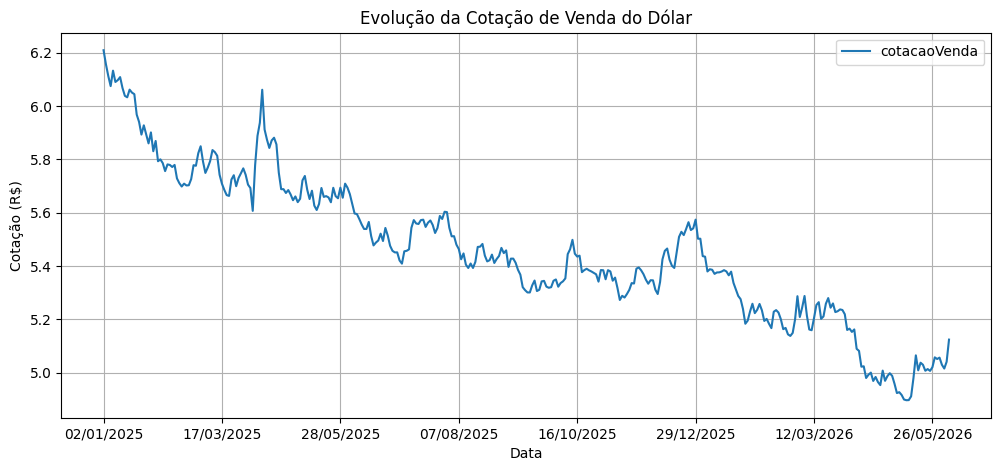

In [21]:
# Cria um gráfico de linha utilizando a coluna "Data" no eixo X
# e a coluna "cotacaoVenda" no eixo Y.
# figsize=(12,5) define o tamanho do gráfico (12 de largura e 5 de altura).

cotação.plot(x='Data', y='cotacaoVenda', figsize=(12,5))

# Adiciona um título ao gráfico.
plt.title('Evolução da Cotação de Venda do Dólar')

# Adiciona o nome do eixo X (horizontal).
plt.xlabel('Data')

# Adiciona o nome do eixo Y (vertical).
plt.ylabel('Cotação (R$)')

# Adiciona uma grade para facilitar a leitura dos valores.
plt.grid(True)

# Exibe o gráfico na tela.
plt.savefig("grafico1_linha.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretação

O gráfico de linha apresenta a evolução da cotação de venda do dólar durante o período analisado.

Observa-se que a cotação iniciou o período em aproximadamente **R$ 6,20** e apresentou uma **tendência geral de queda**, encerrando o período próxima de **R$ 5,10**.

Embora tenham ocorrido pequenas oscilações de alta e baixa ao longo da série temporal, o comportamento predominante foi de desvalorização da cotação do dólar durante o intervalo analisado.

O gráfico permite visualizar de forma clara a evolução da moeda ao longo do tempo e identificar períodos de maior e menor valorização.

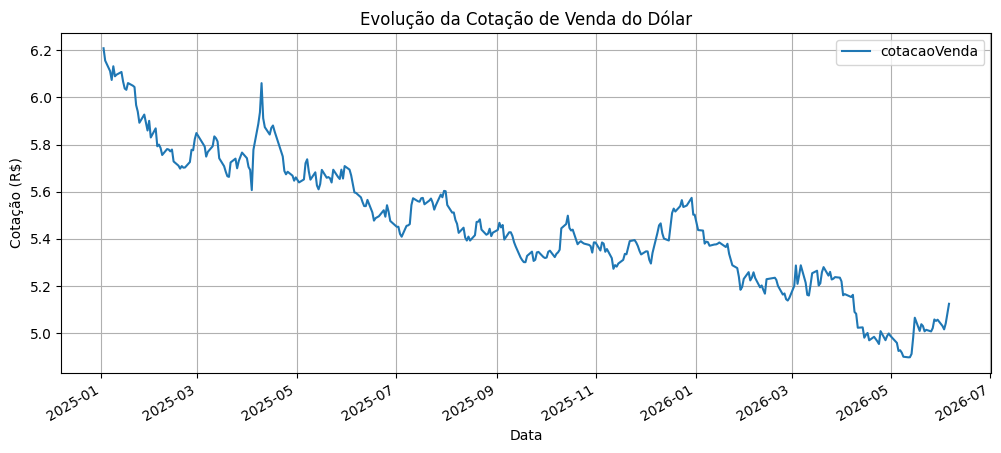

In [22]:
# Cria um gráfico de linha utilizando a coluna "dataHoraCotacao" no eixo X
# e a coluna "cotacaoVenda" no eixo Y.
# figsize=(12,5) define o tamanho do gráfico (12 de largura e 5 de altura).
cotação.plot(x='dataHoraCotacao', y='cotacaoVenda', figsize=(12,5));

# Adiciona um título ao gráfico.
plt.title('Evolução da Cotação de Venda do Dólar')

# Adiciona o nome do eixo X.
plt.xlabel('Data')

# Adiciona o nome do eixo Y.
plt.ylabel('Cotação (R$)')

# Adiciona uma grade para facilitar a leitura dos valores.
plt.grid(True)

# Exibe o gráfico na tela.
plt.savefig("grafico2_linha.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretação

O gráfico de linha apresenta a evolução da cotação de venda do dólar ao longo do período analisado.

No eixo X estão representadas as datas das cotações, enquanto no eixo Y estão os valores da cotação de venda em reais (R$).

Observa-se que a cotação iniciou o período próxima de **R$ 6,20** e, ao longo do tempo, apresentou uma tendência geral de queda, encerrando o período próxima de **R$ 5,10**. Apesar de pequenas oscilações de alta e baixa, o comportamento predominante foi de redução da cotação do dólar durante o período analisado.

Esse gráfico facilita a identificação de tendências e variações da moeda ao longo do tempo.

In [23]:
# Calcula a média da cotação de venda em cada trimestre.
media_trimestre = cotação.groupby('Trimestre')['cotacaoVenda'].mean().round(2)

# Exibe a média da cotação por trimestre.
media_trimestre

Trimestre
1    5.56
2    5.39
3    5.45
4    5.40
Name: cotacaoVenda, dtype: float64

## interpretação
O código agrupa os dados por trimestre e calcula a média da cotação de venda,

Resultado: O 1º trimestre teve a maior média R$ 5,56 e o 2º trimestre a menor R$ 5,39,

Houve uma leve queda seguida de estabilização ao longo do ano,

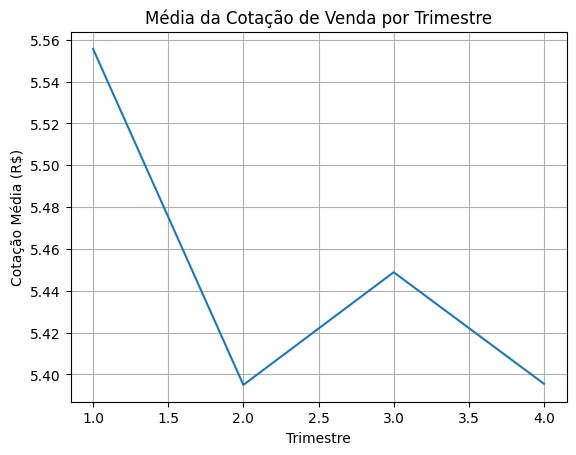

In [24]:
media_trimestre = cotação.groupby('Trimestre')['cotacaoVenda'].mean();

# Cria um gráfico de barras com a média da cotação por trimestre.
media_trimestre.plot(kind='line')

# Adiciona um título ao gráfico.
plt.title('Média da Cotação de Venda por Trimestre')

# Adiciona o nome do eixo X.
plt.xlabel('Trimestre')

# Adiciona o nome do eixo Y.
plt.ylabel('Cotação Média (R$)')

# Adiciona uma grade para facilitar a leitura.
plt.grid(True)

# Exibe o gráfico.
plt.savefig("grafico3_linha.png", dpi=300, bbox_inches="tight")
plt.show()


## Interpretação

O gráfico apresenta a média da cotação de venda do dólar em cada trimestre do período analisado.

Essa análise permite comparar o comportamento da cotação entre os trimestres e identificar em qual período o dólar apresentou a maior e a menor média.

Quanto maior a barra, maior foi a média da cotação de venda do dólar naquele trimestre. Quanto menor a barra, menor foi a média da cotação.

Com esse gráfico, é possível observar a evolução da cotação ao longo dos trimestres e verificar se houve tendência de alta ou de queda durante o período analisado.

In [25]:
# Calcula a diferença da cotação de venda entre um dia e o dia anterior.
cotação['Variação'] = cotação['cotacaoVenda'].diff().round(2)

# Exibe a tabela.
cotação

,cotacaoCompra,cotacaoVenda,dataHoraCotacao,Data,Hora,Ano,Mês,Dia,Dia da Semana,Trimestre,Semana,Variação
0,6.2080,6.2086,2025-01-02 13:09:42.489,02/01/2025,13:09:42,2025,1,2,Quinta-feira,1,1,NaN
1,6.1557,6.1563,2025-01-03 13:07:30.503,03/01/2025,13:07:30,2025,1,3,Sexta-feira,1,1,-0.05
2,6.1113,6.1119,2025-01-06 13:06:28.533,06/01/2025,13:06:28,2025,1,6,Segunda-feira,1,2,-0.04
3,6.0735,6.0741,2025-01-07 13:03:28.766,07/01/2025,13:03:28,2025,1,7,Terça-feira,1,2,-0.04
4,6.1315,6.1321,2025-01-08 13:08:59.784,08/01/2025,13:08:59,2025,1,8,Quarta-feira,1,2,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...
353,5.0563,5.0569,2026-05-29 13:10:26.610,29/05/2026,13:10:26,2026,5,29,Sexta-feira,2,22,0.01
354,5.0297,5.0303,2026-06-01 13:11:27.630,01/06/2026,13:11:27,2026,6,1,Segunda-feira,2,23,-0.03
355,5.0154,5.0160,2026-06-02 13:10:30.711,02/06/2026,13:10:30,2026,6,2,Terça-feira,2,23,-0.01
356,5.0409,5.0415,2026-06-03 13:06:26.540,03/06/2026,13:06:26,2026,6,3,Quarta-feira,2,23,0.03


In [26]:
# a maior alta diária da cotação de venda do dólar.
cotação['Variação'].max()

np.float64(0.17)

## Interpretação

A maior alta diária da cotação de venda do dólar foi de **R$ 0,17**.

Isso significa que, entre dois dias consecutivos, a cotação de venda do dólar aumentou no máximo **17 centavos** durante o período analisado.

In [27]:
# a  maior queda diária da cotação de venda do dólar.
cotação['Variação'].min()

np.float64(-0.15)

## Interpretação

A maior queda diária da cotação de venda do dólar foi de **R$ 0,15**.

Isso significa que, entre dois dias consecutivos do período analisado, a cotação de venda do dólar apresentou uma redução máxima de **15 centavos**.


In [28]:
cotação['cotacaoVenda'].describe().round(2)


count    358.00
mean       5.46
std        0.28
min        4.90
25%        5.29
50%        5.44
75%        5.66
max        6.21
Name: cotacaoVenda, dtype: float64

## Interpretação

O resumo estatístico da coluna **cotacaoVenda** apresentou os seguintes resultados:

- **count (358):** Foram analisados **358 registros** da cotação de venda do dólar.
- **mean (5,46):** A média da cotação de venda durante o período foi de **R$ 5,46**.
- **std (0,28):** O desvio padrão foi de **R$ 0,28**, indicando que as cotações variaram, em média, cerca de 28 centavos em relação à média.
- **min (4,90):** A menor cotação de venda registrada foi de **R$ 4,90**.
- **25% (5,29):** Em 25% dos registros, a cotação foi igual ou inferior a **R$ 5,29**.
- **50% (5,44):** A mediana foi de **R$ 5,44**, indicando que metade das cotações ficou abaixo desse valor e a outra metade acima.
- **75% (5,66):** Em 75% dos registros, a cotação foi igual ou inferior a **R$ 5,66**.
- **max (6,21):** A maior cotação de venda registrada foi de **R$ 6,21**.

De forma geral, observa-se que a cotação de venda do dólar variou entre **R$ 4,90** e **R$ 6,21**, com média de **R$ 5,46**, indicando que os valores permaneceram concentrados próximos dessa média durante o período analisado.

# Conclusão

Neste projeto foi realizada uma análise exploratória da cotação de venda do dólar utilizando a linguagem Python e as bibliotecas Pandas, NumPy e Matplotlib.

Inicialmente, os dados foram importados e preparados para análise. Foram realizadas a conversão dos tipos de dados, o tratamento da coluna de data e hora e a criação de novas colunas para facilitar as análises, como Ano, Mês, Dia, Trimestre e Semana.

Em seguida, foram calculadas diversas estatísticas descritivas, como média, mediana, valor máximo, valor mínimo, desvio padrão e amplitude da cotação de venda do dólar. Também foi analisada a média da cotação por mês e por trimestre, permitindo comparar o comportamento da moeda ao longo do período.

Além das estatísticas, foram desenvolvidos gráficos de  linha para visualizar a evolução da cotação do dólar. Os gráficos facilitaram a identificação das oscilações da moeda e mostraram que, durante o período analisado, a cotação apresentou uma tendência geral de queda, apesar de pequenas variações ao longo do tempo.

Também foi analisada a variação diária da cotação. A maior alta registrada foi de **R$ 0,17**, enquanto a maior queda foi de **R$ 0,15**, demonstrando que ocorreram movimentos diários de valorização e desvalorização da moeda.

Por fim, este projeto permitiu aplicar na prática os principais conceitos de análise exploratória de dados (EDA), como importação, limpeza, transformação, análise estatística e visualização de dados. O desenvolvimento deste trabalho contribuiu para o aprimoramento dos conhecimentos em Python, Pandas e Matplotlib, fortalecendo as habilidades necessárias para atuar na área de Ciência de Dados.